In [1]:
import os
import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from tqdm.auto import tqdm

from model import SmallNet, ResNet18
from train_test import train

matplotlib.style.use('ggplot')

print(torch.__version__) #2.0.1+cu117
torch.cuda.set_device(4)

# define the computation device
device = ('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

2.3.1+cu121
cuda


In [2]:
# define the batch size for data loaders
batch_size = 64
num_classes = 10
transform = transforms.Compose(
    [transforms.Resize((64, 64)),
     transforms.Grayscale(num_output_channels=3),
     transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5))])
# training dataset and data loader
train_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=1)
# validation dataset and data loader
valid_dataset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
validloader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size,
                                         shuffle=False, num_workers=1)

# initialize model
model = ResNet18(num_classes=num_classes)
# load on to computation device
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
save_path = './model-resnet18-bs64-ep10.pth'

if not os.path.exists(save_path):
    train(model, trainloader, validloader, optimizer, criterion, save_path)
model.load_state_dict(torch.load(save_path, map_location='cuda:0'))

<All keys matched successfully>

(10000, 512)


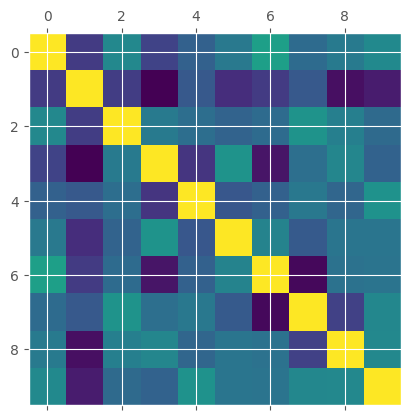

In [19]:
feature_dim = model.get_embedding_dim()
feature_centers = [np.zeros(feature_dim) for _ in range(num_classes)]
example_count = [0] * num_classes
all_features = None
all_labels = []
global_idx = 0
for inputs, targets in validloader:
    inputs = inputs.to(device)
    outputs, embedding, features_blobs = model(inputs)
    for i in range(inputs.shape[0]):
        class_id = targets[i].item()
        feature = embedding[i].detach().cpu().numpy()
        feature_centers[class_id] += feature
        example_count[class_id] += 1
        if all_features is None:
            all_features = np.expand_dims(feature, axis=0)
        else:
            all_features = np.concatenate((all_features, np.expand_dims(feature, axis=0)), axis = 0)
        all_labels.append(class_id)
        global_idx += 1
print(all_features.shape)

for idx in range(num_classes):
    feature_centers[idx] /= example_count[idx]
    #print(feature_centers[idx].max(), feature_centers[idx].min())

from numpy.linalg import norm
def cosine(A, B):
    return np.dot(A,B)/(norm(A)*norm(B))

similarity = np.zeros((num_classes, num_classes))
for i in range(num_classes):
    for j in range(num_classes):
        similarity[i,j] = cosine(feature_centers[i], feature_centers[j])
plt.matshow(similarity)

In [8]:
import cv2
def image_for_visualization(image, sz):
    orig_image = 255 * (image.squeeze(0) * 0.5 + 0.5)
    orig_image = orig_image.cpu().numpy()
    #orig_image = np.repeat(orig_image.astype(np.uint8), 3, 0)
    orig_image = np.transpose(orig_image, (1, 2, 0))
    #print(orig_image)
    image = cv2.resize(orig_image, (sz, sz)) / 255
    return image

In [ ]:
import faiss                     # make faiss available
# res = faiss.StandardGpuResources()  # use a single GPU
index_flat = faiss.IndexFlatL2(feature_dim)  # build a flat (CPU) index

# make it a flat GPU index
# gpu_index_flat = faiss.index_cpu_to_gpu(res, 0, index_flat)
index_flat.add(all_features)         # add vectors to the index

[[   0 9262 5365 7648]
 [   1 9135 1174 5521]
 [   2 1766  204 3809]
 [   3 1777 2333 2873]
 [   4 6536 5101 6265]]
[[ 0.         3.8630626  4.505082   4.915381 ]
 [ 0.         8.106341   8.371089   9.449738 ]
 [ 0.         3.7856953  3.9680617  3.9815955]
 [ 0.         9.654025  10.52163   10.740605 ]
 [ 0.        13.124984  13.359374  13.777482 ]]


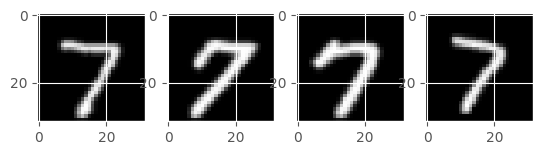

In [18]:
#Test faiss

k = 4                          # we want to see 4 nearest neighbors
D, I = index_flat.search(all_features[:5], k) # sanity check
print(I)
print(D)
fig, axes = plt.subplots(1, k)
for i,ax in enumerate(axes.flat):
    image, _ = valid_dataset[I[0,i]]
    ax.imshow(image_for_visualization(image, 32))

In [69]:
import numpy as np
import cv2
import torch
import glob as glob
from torchvision import transforms
from torch.nn import functional as F
from torch import topk

sz = 64

# https://github.com/zhoubolei/CAM/blob/master/pytorch_CAM.py
def returnCAM(feature_conv, weight_softmax, class_idx, ref_class_idx):
    # generate the class activation maps upsample to 256x256
    size_upsample = (256, 256)
    bz, nc, h, w = feature_conv.shape
    output_cam = []
    #for idx in class_idx:
    if True:
        idx = class_idx
        if ref_class_idx == -1:
          ws = weight_softmax[idx]
        else:
          ws =  weight_softmax[idx] -  weight_softmax[ref_class_idx]
        #print('cam', ws[:5])
        #print(ws.shape, ws)
        cam = ws.dot(feature_conv.reshape((nc, h*w)))
        cam = cam.reshape(h, w)
        cam = cam - np.min(cam)
        cam_img = cam / np.max(cam)
        cam_img = np.uint8(255 * cam_img)
        output_cam.append(cv2.resize(cam_img, size_upsample))
    return output_cam

def Instance_CAM(feature_conv, embedding, ref_class_idx):
    # generate the class activation maps upsample to 256x256
    size_upsample = (256, 256)
    bz, nc, h, w = feature_conv.shape
    output_cam = []
    #for idx in class_idx:
    if True:
        ws = embedding - feature_centers[ref_class_idx]
        #print('inst', ws[:5])
        #print(ws.shape, ws)
        cam = ws.dot(feature_conv.reshape((nc, h*w)))
        cam = cam.reshape(h, w)
        #cam[cam < 0] = 0
        cam = cam - np.min(cam)
        cam_img = cam / np.max(cam)
        cam_img = np.uint8(255 * cam_img)
        output_cam.append(cv2.resize(cam_img, size_upsample))
    return output_cam

def Instance_CAM_knn(feature_conv, embedding, ref_class_idx):
    # generate the class activation maps upsample to 256x256
    size_upsample = (256, 256)
    bz, nc, h, w = feature_conv.shape
    output_cam = []
    K = 10
    N = 1
    D, I = index_flat.search(np.expand_dims(embedding, axis=0), K) # sanity check
    counter_center = None
    num = 0
    for i in range(1, K):
        idx = I[0, i]
        if all_labels[idx] != ref_class_idx:
            continue
        if counter_center is None:
            counter_center = all_features[idx]
        else:
            counter_center += all_features[idx]
        num += 1
        if num >= N:
            break

    counter_center /= num
    #for idx in class_idx:
    if True:
        ws = embedding - counter_center
        #print('inst', ws[:5])
        #print(ws.shape, ws)
        cam = ws.dot(feature_conv.reshape((nc, h*w)))
        cam = cam.reshape(h, w)
        #cam[cam < 0] = 0
        cam = cam - np.min(cam)
        cam_img = cam / np.max(cam)
        cam_img = np.uint8(255 * cam_img)
        output_cam.append(cv2.resize(cam_img, size_upsample))
    return output_cam
    
def show_cam(CAMs, orig_image):
    width, height = orig_image.shape[:2]
    for i, cam in enumerate(CAMs):
        heatmap = cv2.applyColorMap(cv2.resize(cam,(width, height)), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

        result = heatmap * 0.5 + orig_image * 0.5
        image = cv2.resize(orig_image, (sz, sz)) / 255
        result = cv2.resize(result, (sz, sz)) / 255

        return result


In [70]:
# get the softmax weight
params = list(model.parameters())
weight_softmax = np.squeeze(params[-2].data.cpu().numpy())
print(weight_softmax.shape)

ref_config = {6: [8,0,4], 3: [5,2,8], 9: [0,7,8], 8:[0,6,9]}
#ref_config = {1: [9,4,7]}

target_ids = list(ref_config.keys())
num_examples = 5

demo_set = []
count = [0] * 10
for tid in target_ids:
    count[tid] = num_examples

for image, label in valid_dataset:
    if count[label] == 0:
        continue
    count[label] -= 1
    demo_set.append((image, label))
demo_set = sorted(demo_set, key = lambda d:d[1])

print(len(demo_set))


(10, 512)
20


/tmp/ipykernel_2250822/471588949.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(outputs).data.squeeze()


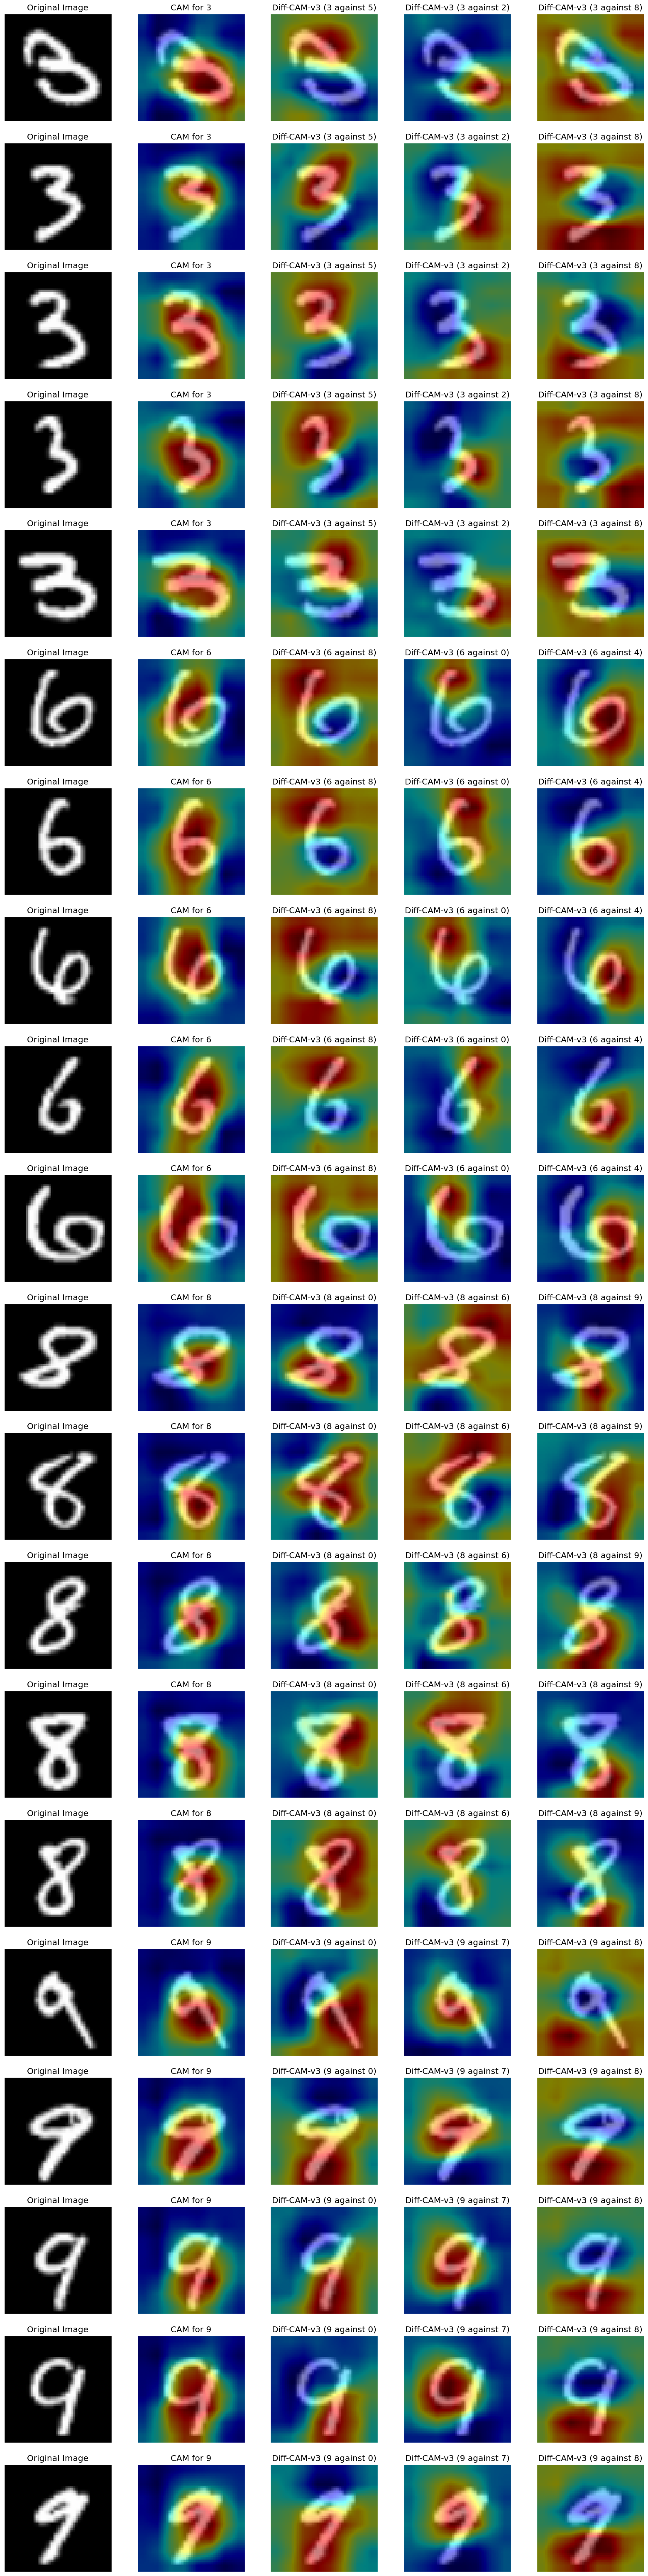

In [71]:
results = []
for image, target_id in demo_set:
    # forward pass through model
    image = image.unsqueeze(0)
    #features_blobs.clear()
    outputs, embedding, features_blobs = model(image.cuda())
    # get the softmax probabilities
    probs = F.softmax(outputs).data.squeeze()
    # get the class indices of top k probabilities
    class_idx = topk(probs, 1)[1].int()
    #print(class_idx)

    orig_image = 255 * (image.squeeze(0) * 0.5 + 0.5)
    orig_image = orig_image.cpu().numpy()
    #orig_image = np.repeat(orig_image.astype(np.uint8), 3, 0)
    orig_image = np.transpose(orig_image, (1, 2, 0))
    #print(orig_image)

    image = cv2.resize(orig_image, (sz, sz)) / 255
    results.append((image, 'Original Image'))

    feature = features_blobs[-1].cpu().detach()
    #print(feature.shape)

    # generate class activation mapping for the top1 prediction
    CAMs = returnCAM(feature, weight_softmax, target_id, -1)
    ret = show_cam(CAMs, orig_image)
    results.append((ret, 'CAM for %d' % target_id))

    for ref_id in ref_config[target_id]:
        # generate class activation mapping for the top1 prediction
        #CAMs = returnCAM(feature, weight_softmax, target_id, ref_id)
        CAMs = Instance_CAM_knn(feature, embedding[0].detach().cpu().numpy(), ref_id)
        ret = show_cam(CAMs, orig_image)
        results.append((ret, 'Diff-CAM-v3 (%d against %d)' % (target_id, ref_id)))


col_size = 2 + len(ref_config[target_ids[0]])
row_size = len(demo_set)

fig, axes = plt.subplots(row_size, col_size, figsize=(col_size*4, row_size*4))
for i,ax in enumerate(axes.flat):
    interp, title = results[i]
    ax.imshow(interp)
    ax.set_title(title)
    # Hide grid lines
    ax.grid(False)
    # Hide axes ticks
    ax.set_xticks([])
    ax.set_yticks([])

plt.savefig('diff-cam-result-v3.png')